
simulation stochastique 2

mouvement brownien

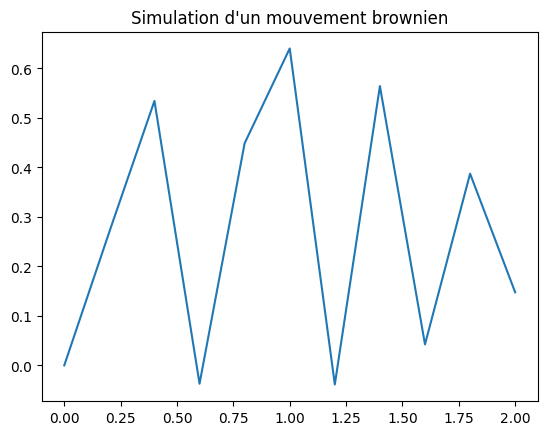

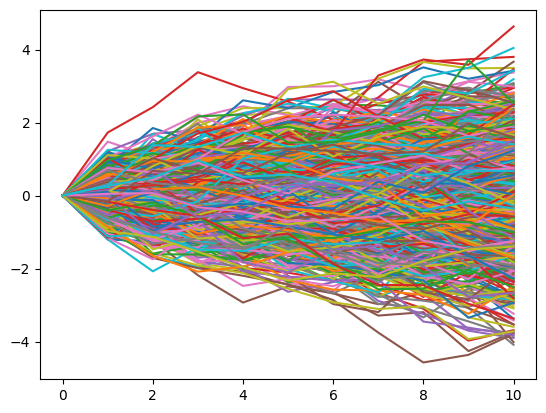

esp MC MB: -0.017866456254574458
var MC MB: 1.9785823710596502
resultat MC: 2.3337108047048702
resultat TH: 2.2479079866764717


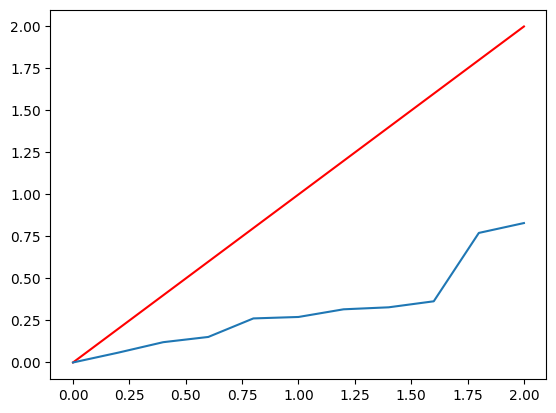

In [43]:
import numpy as np
import matplotlib.pyplot as plt

N = 10       
T = 2            
delta_t = T / N  

W = np.zeros(N + 1)  
t = np.zeros(N + 1)  
W[0]=0
for i in range(N):
    W[i + 1] = W[i] + np.sqrt(delta_t) * np.random.randn()
    t[i + 1] = t[i] + delta_t

plt.plot(t, W)
plt.title("Simulation d'un mouvement brownien")
plt.show()

Nmc = 1000
last_value = np.zeros(Nmc)
last_value_carre = np.zeros(Nmc)

for n in range(Nmc):
    W[0] = 0
    for i in range(N):
        W[i + 1] = W[i] + np.sqrt(delta_t) * np.random.randn()
    last_value[n] = W[N]
    last_value_carre[n] = W[N]**2
    plt.plot(W)
plt.show()
esp_MC_MB = np.mean(last_value)
var_MC_MB = np.mean(last_value_carre)-(esp_MC_MB)**2

print("esp MC MB:",esp_MC_MB)
print("var MC MB:",var_MC_MB)

sum=0
u=0.9
t=2
for i in range(1,Nmc):
    W[0]=0
    for i in range(N):
        W[i + 1] = W[i] + np.sqrt(delta_t) * np.random.randn()
    sum = sum + np.exp(u*W[N])
    
result_MC = sum/Nmc
result_th = np.exp(t*u**2/2)

print("resultat MC:",result_MC)
print("resultat TH:",result_th)

Nmc1 = 1000
Q = np.zeros(N + 1)
t = np.zeros(N + 1)
Q[0] = 0
t[0] = 0

for k in range(0,N):
    

    W[k + 1] = W[k] + np.sqrt(delta_t) * np.random.randn()
    Q[k + 1] = Q[k] + (W[k + 1] - W[k])**2
    t[k + 1] = t[k] + delta_t

plt.plot(t, t, 'r')
plt.plot(t, Q)
plt.show()




variation quadratique

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def I_sto():
    N = 10000         
    T = 2           
    delta_t = T / N
    I = 0
    W = np.zeros(N + 1)  

    for i in range(N):
        W[i+1] = W[i] + np.sqrt(delta_t) * np.random.randn()
        theta = W[i]
        I += theta * (W[i+1] - W[i])   

    return I

Nmc = 1000           
I = np.zeros(Nmc)   

for n in range(Nmc):
    I[n] = I_sto()

esp_I = np.mean(I)
print("Espérance de I ≈", esp_I)


    

Espérance de I ≈ -0.1286746066722808


In [11]:
I = 0
T=2
N=10000
W = np.zeros(N + 1)  
delta_t = T/N
for i in range(0,N):
    W[i+1] = W[i] + np.sqrt(delta_t) * np.random.randn()
    theta = W[i]
    I += theta * (W[i+1] - W[i])

partie_gauche = I
partie_droite = (W[N])**2/2 -T/2
print(partie_gauche)
print(partie_droite)

-0.9790819397404058
-0.9607431682729407


[2, np.float64(2.060764446812139), np.float64(2.0493334620506016), np.float64(2.04375013512522), np.float64(2.0848873951345595), np.float64(2.0669355481438547), np.float64(2.0512633493473027), np.float64(2.107442824762934), np.float64(2.0269029685975117), np.float64(1.9922950222750815), np.float64(1.936816795641672), np.float64(1.9575430399083102), np.float64(1.9923670744288082), np.float64(2.116307474190597), np.float64(2.150209757074949), np.float64(2.13632776052192), np.float64(2.0308564416324995), np.float64(2.123945478931279), np.float64(2.0519822120138307), np.float64(2.116690262049518), np.float64(2.0236315248727985), np.float64(1.8948948591050931), np.float64(1.828602535549218), np.float64(1.8593027557198503), np.float64(1.953010067531302), np.float64(1.9082997597972602), np.float64(1.9413844860564047), np.float64(1.9982431344749265), np.float64(1.915126151198642), np.float64(2.0062289812484693), np.float64(1.968838801204002), np.float64(1.8734572463131283), np.float64(1.860203

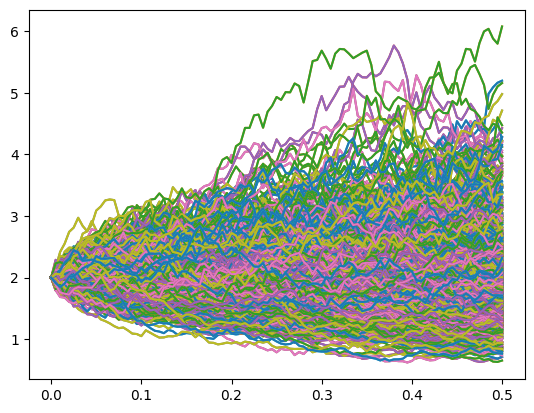

In [122]:

def Trajectoire(S0):
    S = [S0]
    r = 0.1 
    sigma = 0.5
    T = 0.5
    N = 100
    delta_t = T/N
    t = np.linspace(0,T,N+1)
    for i in range(N):
        S.append(S[i]*np.exp((r-sigma**2/2)*delta_t + sigma * np.sqrt(delta_t)*np.random.randn()))
    plt.plot(t,S)
    #plt.show()
    return S
print(Trajectoire(2))

Nmc = 1000
s_values = np.zeros(Nmc)
t = np.linspace(0, T, N+1)
for n in range(Nmc):
    s_traj = Trajectoire(2)
    s_values[n] = s_traj[-1]
    plt.plot(t, s_traj)
plt.show()



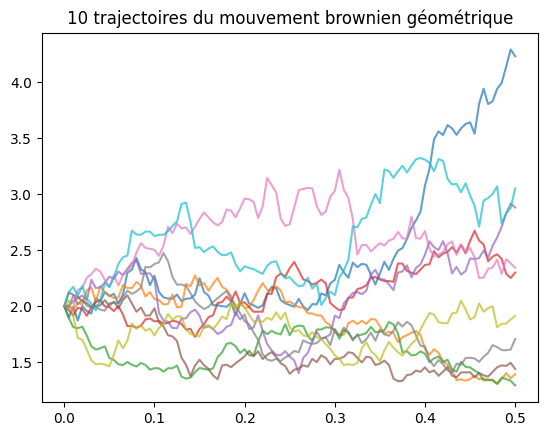

Valeurs finales S(T) : [4.22933499 1.39522343 1.29321342 2.2998277  2.88061658 1.44077508
 2.34365643 1.7071107  1.91295615 3.05082553]


In [115]:
import numpy as np
import matplotlib.pyplot as plt

def Trajectoire(S0):
    S = [S0]
    r = 0.1
    sigma = 0.5
    T = 0.5
    N = 100
    delta_t = T / N
    t = np.linspace(0, T, N+1)
    for i in range(N):
        S.append(S[i] * np.exp((r - 0.5 * sigma**2) * delta_t + sigma * np.sqrt(delta_t) * np.random.randn()))
    return S, t

# Simulation Monte Carlo
Nmc = 10
s_values = np.zeros(Nmc)


for i in range(Nmc):
    S_traj, t = Trajectoire(2)
    s_values[i] = S_traj[-1]
    plt.plot(t, S_traj, alpha=0.7)  # tracer chaque trajectoire

plt.title(f"{Nmc} trajectoires du mouvement brownien géométrique")
plt.show()

print("Valeurs finales S(T) :", s_values)




pour f(t,x)=tsin(x)

In [2]:
import numpy as np


T = 2
N = 10000
delta_t = T / N
I_stoch = 0
I_ponderee = 0

W = np.zeros(N + 1)
for i in range(N):
    W[i+1] = W[i] + np.sqrt(delta_t) * np.random.randn() #simulation du mouvement brownien
    t_i = i * delta_t                                    #définition du temps
    I_stoch += t_i * np.cos(W[i]) * (W[i+1] - W[i])      #partie gauche somme de riemann pour integrale stochastique    
    I_ponderee += (1 - t_i/2) * np.sin(W[i]) * delta_t   #on utilise la somme de riemann  

partie_gauche = I_stoch
partie_droite = T * np.sin(W[N]) - I_ponderee

print("Partie gauche :", partie_gauche)
print("Partie droite  :", partie_droite)


Partie gauche : 1.222930612997762
Partie droite  : 1.2343107359769632


In [1]:
import numpy as np

def I_sto():
    N = 10000         
    T = 2           
    delta_t = T / N
    I_stoch = 0
    I_ponderee = 0
    W = np.zeros(N + 1)  

    for i in range(N):
        W[i+1] = W[i] + np.sqrt(delta_t) * np.random.randn() #simulation du mouvement brownien
        t_i = i * delta_t                                    #définition du temps
        I_stoch += t_i * np.cos(W[i]) * (W[i+1] - W[i])      #partie gauche somme de riemann pour integrale stochastique    
        I_ponderee += (1 - t_i/2) * np.sin(W[i]) * delta_t   #on utilise la somme de riemann   

    return I_stoch

Nmc = 1000           
I = np.zeros(Nmc)   

for n in range(Nmc):
    I[n] = I_sto()

esp_I = np.mean(I)
print("Espérance de I ≈", esp_I)

Espérance de I ≈ -0.03040558776626554
